# De novo generation of UV-absorbing molecules

This notebook is a deliberately small, auditable baseline. It does **not** decorate a fixed
scaffold and does **not** enumerate a synthon library. A token GRU learns the SELFIES language
of experimental UV/Vis molecules and is then fine-tuned with REINFORCE. Its reward is produced
by an independently trained Morgan-fingerprint Random-Forest ensemble.

**What the result means:** the exported structures are new relative to the downloaded UVVisML
table, valid according to RDKit, pass conservative structural filters, and have a model-predicted
absorption maximum in or near the configured UV window. This is computational prioritisation,
not proof of absorption, safety, or laboratory synthesis. In particular, $\lambda_{max}$ does not
measure absorption strength. PAINS/Brenk and SA Score are heuristics, not toxicology or
retrosynthesis. Experimental/quantum validation is required before making a physical claim.

Default target: **300–400 nm**. All important limits, seeds, and training sizes are in one config
cell below. CPU defaults are intentionally modest; CUDA automatically enables a somewhat longer
run.

## 1. Reproducible configuration

Required packages: `numpy`, `pandas`, `scikit-learn`, `rdkit`, `torch`, `selfies`, `requests`,
`matplotlib`, `joblib`, and `jupyter`. The repository environment should install pinned versions;
this notebook intentionally does not mutate its own environment with `pip install`.

In [1]:
from __future__ import annotations

import copy
import hashlib
import importlib.metadata as importlib_metadata
import json
import math
import os
import platform
import random
import subprocess
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import selfies as sf
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem, DataStructs, RDConfig, RDLogger, rdBase
from rdkit.Chem import Descriptors, Lipinski, QED, rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset


SEED = 20260917
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@dataclass(frozen=True)
class Config:
    # Official combined molecule-grouped splits. Content hashes are recorded below.
    source_urls: tuple[str, ...] = (
        "https://raw.githubusercontent.com/learningmatter-mit/uvvisml/main/uvvisml/data/splits/"
        "lambda_max_abs/combined/group_by_smiles/smiles_target_train.csv",
        "https://raw.githubusercontent.com/learningmatter-mit/uvvisml/main/uvvisml/data/splits/"
        "lambda_max_abs/combined/group_by_smiles/smiles_target_val.csv",
        "https://raw.githubusercontent.com/learningmatter-mit/uvvisml/main/uvvisml/data/splits/"
        "lambda_max_abs/combined/group_by_smiles/smiles_target_test.csv",
    )
    target_low_nm: float = 300.0
    target_high_nm: float = 400.0
    target_softness_nm: float = 12.0
    uncertainty_margin: float = 1.0
    uncertainty_scale_nm: float = 45.0
    morgan_radius: int = 2
    fingerprint_bits: int = 2048
    rf_members: int = 5
    rf_trees_per_member: int = 120
    max_training_molecules: int = 15000
    embedding_dim: int = 192
    hidden_dim: int = 256
    gru_layers: int = 2
    prior_epochs_cpu: int = 4
    prior_epochs_cuda: int = 7
    prior_batch_size: int = 128
    max_selfies_tokens: int = 100
    rl_steps_cpu: int = 300
    rl_steps_cuda: int = 550
    rl_batch_size: int = 96
    rl_learning_rate: float = 2.0e-4
    kl_weight: float = 0.03
    entropy_weight: float = 0.002
    sampling_temperature: float = 0.95
    final_samples_cpu: int = 3000
    final_samples_cuda: int = 7000
    final_batch_size: int = 256
    mw_min: float = 120.0
    mw_max: float = 600.0
    max_sa_score: float = 6.0
    max_psoralen_similarity: float = 0.45
    max_rotatable_bonds: int = 12
    min_qed: float = 0.15
    ad_reference_size: int = 1500


CFG = Config()
ROOT = Path.cwd().resolve()
CACHE_DIR = ROOT / "data" / "cache" / "uvvisml"
OUTPUT_DIR = ROOT / "outputs" / "uv_denovo"
MODEL_DIR = OUTPUT_DIR / "models"
for directory in (CACHE_DIR, OUTPUT_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


# RDKit parse failures are counted in the data/audit tables below.  Suppress its
# per-molecule stderr spam so an executed notebook remains readable.
RDLogger.DisableLog("rdApp.*")

seed_everything()
PRIOR_EPOCHS = CFG.prior_epochs_cuda if DEVICE.type == "cuda" else CFG.prior_epochs_cpu
RL_STEPS = CFG.rl_steps_cuda if DEVICE.type == "cuda" else CFG.rl_steps_cpu
FINAL_SAMPLES = CFG.final_samples_cuda if DEVICE.type == "cuda" else CFG.final_samples_cpu
print(f"root={ROOT}")
print(f"device={DEVICE}; prior_epochs={PRIOR_EPOCHS}; rl_steps={RL_STEPS}; final_samples={FINAL_SAMPLES}")

/home/dokoo-lua/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-pz3vnj3v because there was an issue with the default path (/home/dokoo-lua/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


root=/home/dokoo-lua/MolGeneration
device=cpu; prior_epochs=4; rl_steps=300; final_samples=3000


## 2. Download and cache the official UVVisML tables

The official `combined/group_by_smiles` train, validation, and test CSV files are downloaded from
the UVVisML repository. A SHA-256 digest of every downloaded file is recorded in the run manifest.
The source combines experimental measurements from several publications; see
the [UVVisML data documentation](https://github.com/learningmatter-mit/uvvisml/tree/72b2a3ea391f39b8300cefeafd71cae340634740/uvvisml/data).

In [2]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def download_cached(url: str, destination: Path) -> Path:
    if destination.exists() and destination.stat().st_size > 1000:
        print(f"Using cached dataset: {destination}")
        return destination
    temporary = destination.with_suffix(destination.suffix + ".part")
    with requests.get(url, stream=True, timeout=(15, 120)) as response:
        response.raise_for_status()
        with temporary.open("wb") as handle:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    handle.write(chunk)
    if temporary.stat().st_size <= 1000:
        raise RuntimeError("Downloaded UVVisML file is unexpectedly small")
    temporary.replace(destination)
    return destination


RAW_DATA_PATHS = {}
SOURCE_SHA256 = {}
for source_url in CFG.source_urls:
    filename = source_url.rsplit("/", 1)[-1]
    path = download_cached(source_url, CACHE_DIR / filename)
    RAW_DATA_PATHS[filename] = path
    SOURCE_SHA256[filename] = sha256_file(path)
    print(f"{filename}: bytes={path.stat().st_size:,}; sha256={SOURCE_SHA256[filename]}")

Using cached dataset: /home/dokoo-lua/MolGeneration/data/cache/uvvisml/smiles_target_train.csv
smiles_target_train.csv: bytes=1,726,547; sha256=53bbac67b99c52cd6f271de78a141b484ece68e1b64705d1547e2a17bdb87902
Using cached dataset: /home/dokoo-lua/MolGeneration/data/cache/uvvisml/smiles_target_val.csv
smiles_target_val.csv: bytes=208,402; sha256=e1fb954af3e654d25ac49d1310ec64868186dabd5049bfcf71222b3221f0a947
Using cached dataset: /home/dokoo-lua/MolGeneration/data/cache/uvvisml/smiles_target_test.csv
smiles_target_test.csv: bytes=207,596; sha256=9f5141263370ea74dfe10b9691a75ff507abe5abffee47688e47eac7eccbb428


## 3. Standardise labels and molecules

The reviewer is molecule-only, so repeated solvent/condition measurements are aggregated to the
median $\lambda_{max}$ for each canonical structure. This simplification is explicit: the model
does not represent solvatochromic shifts. We retain the count and within-molecule spread for audit.

The standardisation keeps the largest fragment, applies RDKit cleanup and uncharging, sanitises
the molecule, and permits only common organic elements. Exact canonical duplicates are then
aggregated.

In [3]:
ALLOWED_ATOMIC_NUMBERS = {1, 5, 6, 7, 8, 9, 14, 15, 16, 17, 35, 53}
_uncharger = rdMolStandardize.Uncharger()


def standardize_smiles(value: object) -> str | None:
    if value is None or pd.isna(value):
        return None
    try:
        mol = Chem.MolFromSmiles(str(value), sanitize=True)
        if mol is None:
            return None
        mol = rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.FragmentParent(mol)
        mol = _uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        if any(atom.GetAtomicNum() not in ALLOWED_ATOMIC_NUMBERS for atom in mol.GetAtoms()):
            return None
        if not mol.GetNumHeavyAtoms():
            return None
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None


raw_parts = []
for source_split, filename in (
    ("upstream_train", "smiles_target_train.csv"),
    ("upstream_validation", "smiles_target_val.csv"),
    ("upstream_test", "smiles_target_test.csv"),
):
    part = pd.read_csv(RAW_DATA_PATHS[filename], low_memory=False)
    part["upstream_split"] = source_split
    raw_parts.append(part)
raw = pd.concat(raw_parts, ignore_index=True)
required_columns = {"smiles", "peakwavs_max"}
missing = required_columns.difference(raw.columns)
if missing:
    raise KeyError(f"UVVisML schema changed; missing columns: {sorted(missing)}")

clean = pd.DataFrame(
    {
        "canonical_smiles": raw["smiles"].map(standardize_smiles),
        "lambda_max_nm": pd.to_numeric(raw["peakwavs_max"], errors="coerce"),
        "solvent": raw.get("solvent", pd.Series("unknown", index=raw.index)).fillna("unknown"),
        "source": raw["upstream_split"],
    }
)
clean = clean.dropna(subset=["canonical_smiles", "lambda_max_nm"])
clean = clean[clean["lambda_max_nm"].between(180.0, 900.0)].copy()

uv_data = (
    clean.groupby("canonical_smiles", as_index=False)
    .agg(
        lambda_max_nm=("lambda_max_nm", "median"),
        observation_count=("lambda_max_nm", "size"),
        lambda_within_std_nm=("lambda_max_nm", "std"),
        source_count=("source", "nunique"),
        solvent_count=("solvent", "nunique"),
    )
    .fillna({"lambda_within_std_nm": 0.0})
    .sort_values("canonical_smiles")
    .reset_index(drop=True)
)

# Content-derived truncation, if ever needed, is independent of source row order.
uv_data["content_hash"] = uv_data["canonical_smiles"].map(
    lambda text: hashlib.sha256(text.encode("utf-8")).hexdigest()
)
if len(uv_data) > CFG.max_training_molecules:
    uv_data = uv_data.nsmallest(CFG.max_training_molecules, "content_hash").copy()

print(f"raw rows={len(raw):,}; usable measurements={len(clean):,}; unique molecules={len(uv_data):,}")
display(uv_data.drop(columns="content_hash").head())

raw rows=26,395; usable measurements=26,265; unique molecules=14,822


,canonical_smiles,lambda_max_nm,observation_count,lambda_within_std_nm,source_count,solvent_count
0,B1C=Cc2c(ccc3ccccc23)N1,345.0,1,0.0,1,1
1,B1C=Cc2cc3c(cc2N1)C=CBN3,357.0,1,0.0,1,1
2,B1C=Cc2cc3ccccc3cc2N1,359.0,1,0.0,1,1
3,B1C=Cc2ccc3ccccc3c2N1,351.5,1,0.0,1,1
4,B1Nc2cccc3c2-n2c1ccc2BN3,316.0,1,0.0,1,1


## 4. Scaffold split

The UV reviewer is evaluated on held-out Bemis–Murcko scaffolds rather than a random row split.
The generator prior is also trained only on the reviewer training split. The complete UVVisML
molecule set remains the novelty exclusion set.

In [4]:
def scaffold_key(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return scaffold or smiles


uv_data["scaffold"] = uv_data["canonical_smiles"].map(scaffold_key)
all_indices = np.arange(len(uv_data))
outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, holdout_idx = next(outer.split(all_indices, groups=uv_data["scaffold"]))
inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED + 1)
val_rel, test_rel = next(
    inner.split(holdout_idx, groups=uv_data.iloc[holdout_idx]["scaffold"])
)
split = np.full(len(uv_data), "train", dtype=object)
split[holdout_idx[val_rel]] = "validation"
split[holdout_idx[test_rel]] = "test"
uv_data["split"] = split

split_summary = uv_data.groupby("split").agg(
    molecules=("canonical_smiles", "size"), scaffolds=("scaffold", "nunique")
)
assert uv_data.groupby("scaffold")["split"].nunique().max() == 1
display(split_summary)

,molecules,scaffolds
split,,
test,1500,742
train,11855,5933
validation,1467,742


## 5. UV reviewer: Morgan fingerprints + Random-Forest ensemble

Five independently seeded forests predict $\lambda_{max}$. Their mean is the reward signal and
their between-member standard deviation is a lightweight uncertainty proxy. It is **not** a fully
calibrated confidence interval; the reward also penalises candidates far from a reference sample
of training fingerprints.

In [5]:
FP_GENERATOR = rdFingerprintGenerator.GetMorganGenerator(
    radius=CFG.morgan_radius, fpSize=CFG.fingerprint_bits
)


def bit_fingerprint(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid canonical SMILES: {smiles}")
    return FP_GENERATOR.GetFingerprint(mol)


def fingerprint_matrix(smiles_values) -> np.ndarray:
    matrix = np.zeros((len(smiles_values), CFG.fingerprint_bits), dtype=np.uint8)
    for row_index, smiles in enumerate(smiles_values):
        DataStructs.ConvertToNumpyArray(bit_fingerprint(smiles), matrix[row_index])
    return matrix


X = fingerprint_matrix(uv_data["canonical_smiles"].tolist())
y = uv_data["lambda_max_nm"].to_numpy(dtype=np.float32)
train_mask = uv_data["split"].eq("train").to_numpy()
validation_mask = uv_data["split"].eq("validation").to_numpy()
test_mask = uv_data["split"].eq("test").to_numpy()

reviewer_models = []
for member in range(CFG.rf_members):
    model = RandomForestRegressor(
        n_estimators=CFG.rf_trees_per_member,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=SEED + 100 + member,
    )
    model.fit(X[train_mask], y[train_mask])
    reviewer_models.append(model)


def predict_matrix_raw(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    member_predictions = np.stack([model.predict(matrix) for model in reviewer_models], axis=0)
    return member_predictions.mean(axis=0), member_predictions.std(axis=0, ddof=0)


validation_mean_raw, validation_std_raw = predict_matrix_raw(X[validation_mask])
validation_residuals = np.abs(y[validation_mask] - validation_mean_raw)
CONFORMAL_Q90_NM = float(np.quantile(validation_residuals, 0.90, method="higher"))
Z90 = 1.645


def predict_matrix(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean, ensemble_std = predict_matrix_raw(matrix)
    # RF member disagreement is commonly overconfident.  Floor it with the
    # validation split-conformal residual radius expressed on a sigma scale.
    calibrated_std = np.maximum(ensemble_std, CONFORMAL_Q90_NM / Z90)
    return mean, calibrated_std


def regression_metrics(mask: np.ndarray, split_name: str) -> dict:
    mean, std = predict_matrix(X[mask])
    truth = y[mask]
    return {
        "split": split_name,
        "n": int(mask.sum()),
        "mae_nm": float(mean_absolute_error(truth, mean)),
        "rmse_nm": float(mean_squared_error(truth, mean) ** 0.5),
        "r2": float(r2_score(truth, mean)),
        "mean_calibrated_std_nm": float(std.mean()),
        "conformal_q90_nm": CONFORMAL_Q90_NM,
        "interval_90_coverage": float(np.mean(np.abs(truth - mean) <= CONFORMAL_Q90_NM)),
    }


reviewer_metrics = pd.DataFrame(
    [
        regression_metrics(validation_mask, "validation"),
        regression_metrics(test_mask, "test"),
    ]
)
display(reviewer_metrics)
reviewer_metrics.to_csv(OUTPUT_DIR / "reviewer_metrics.csv", index=False)

joblib.dump(
    {
        "models": reviewer_models,
        "config": asdict(CFG),
        "source_sha256": SOURCE_SHA256,
        "target_name": "median experimental lambda_max_nm per canonical molecule",
        "conformal_q90_nm": CONFORMAL_Q90_NM,
        "uncertainty": "max(RF ensemble std, validation split-conformal q90 / 1.645)",
    },
    MODEL_DIR / "uv_rf_ensemble.joblib",
)

,split,n,mae_nm,rmse_nm,r2,mean_calibrated_std_nm,conformal_q90_nm,interval_90_coverage
0,validation,1467,41.335953,57.732799,0.699867,58.088587,95.555726,0.899796
1,test,1500,38.329952,53.889762,0.753218,58.088587,95.555726,0.926667


['/home/dokoo-lua/MolGeneration/outputs/uv_denovo/models/uv_rf_ensemble.joblib']

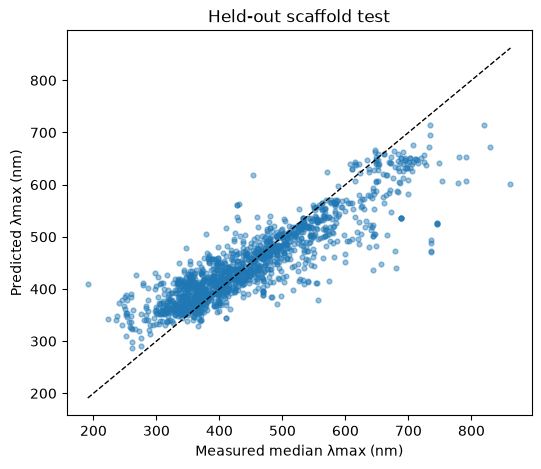

In [6]:
test_mean, test_std = predict_matrix(X[test_mask])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y[test_mask], test_mean, s=12, alpha=0.45)
limits = [float(min(y[test_mask].min(), test_mean.min())), float(max(y[test_mask].max(), test_mean.max()))]
ax.plot(limits, limits, "k--", linewidth=1)
ax.set(xlabel="Measured median λmax (nm)", ylabel="Predicted λmax (nm)", title="Held-out scaffold test")
plt.show()

## 6. Conservative structural and synthesizability filters

Candidates must be RDKit-valid, single-fragment standardised organic molecules, contain only the
configured elements, avoid explicit psoralen/angelicin (furocoumarin) cores, and pass RDKit PAINS
and Brenk alerts. Additional hard bounds are molecular weight, rotatable bonds, formal charge,
QED, and the RDKit-contributed Ertl synthetic-accessibility score.

These filters reduce obvious failure modes but cannot establish non-toxicity or an executable
synthesis route. Brenk/PAINS alerts can also reject benign chromophores; rejected reasons are kept
in the audit table rather than hidden.

In [7]:
contrib_sa_path = Path(RDConfig.RDContribDir) / "SA_Score"
if str(contrib_sa_path) not in sys.path:
    sys.path.insert(0, str(contrib_sa_path))
try:
    import sascorer
except ImportError as error:
    raise ImportError(
        f"RDKit SA_Score was not found at {contrib_sa_path}; install a full RDKit distribution"
    ) from error

catalog_params = FilterCatalogParams()
for catalog_name in (
    FilterCatalogParams.FilterCatalogs.PAINS_A,
    FilterCatalogParams.FilterCatalogs.PAINS_B,
    FilterCatalogParams.FilterCatalogs.PAINS_C,
    FilterCatalogParams.FilterCatalogs.BRENK,
):
    catalog_params.AddCatalog(catalog_name)
STRUCTURAL_ALERTS = FilterCatalog(catalog_params)

# Linear and angular furocoumarin cores. Molecule queries allow substituted derivatives to match.
FUROCOUMARIN_SMILES = {
    "psoralen_core": "C1=CC(=O)OC2=CC3=C(C=CO3)C=C21",
    "angelicin_core": "C1=CC2=C(C=CO2)C3=C1C=CC(=O)O3",
}
FUROCOUMARIN_QUERIES = {
    name: Chem.MolFromSmiles(pattern) for name, pattern in FUROCOUMARIN_SMILES.items()
}
if any(query is None for query in FUROCOUMARIN_QUERIES.values()):
    raise RuntimeError("Internal furocoumarin query failed to parse")
KNOWN_PSORALEN_SMILES = (
    "C1=CC(=O)OC2=CC3=C(C=CO3)C=C21",
    "C1=CC2=C(C=CO2)C3=C1C=CC(=O)O3",
    "COC1=C2C=CC(=O)OC2=CC3=C1C=CO3",
)
KNOWN_PSORALEN_FPS = [
    FP_GENERATOR.GetFingerprint(Chem.MolFromSmiles(pattern))
    for pattern in KNOWN_PSORALEN_SMILES
]


def hard_filter(smiles: str) -> dict:
    canonical = standardize_smiles(smiles)
    base = {
        "input_smiles": smiles,
        "canonical_smiles": canonical,
        "passes_hard_filters": False,
        "filter_reason": "invalid_smiles",
        "molecular_weight": np.nan,
        "sa_score": np.nan,
        "qed": np.nan,
        "rotatable_bonds": np.nan,
        "psoralen_similarity": np.nan,
    }
    if canonical is None:
        return base
    mol = Chem.MolFromSmiles(canonical)
    assert mol is not None
    base["canonical_smiles"] = canonical
    base["molecular_weight"] = float(Descriptors.MolWt(mol))
    base["sa_score"] = float(sascorer.calculateScore(mol))
    base["qed"] = float(QED.qed(mol))
    base["rotatable_bonds"] = int(Lipinski.NumRotatableBonds(mol))
    molecule_fp = FP_GENERATOR.GetFingerprint(mol)
    base["psoralen_similarity"] = float(
        max(DataStructs.BulkTanimotoSimilarity(molecule_fp, KNOWN_PSORALEN_FPS))
    )

    checks = [
        (mol.GetNumHeavyAtoms() < 8, "too_few_heavy_atoms"),
        (mol.GetNumHeavyAtoms() > 50, "too_many_heavy_atoms"),
        (not CFG.mw_min <= base["molecular_weight"] <= CFG.mw_max, "molecular_weight"),
        (base["rotatable_bonds"] > CFG.max_rotatable_bonds, "too_many_rotatable_bonds"),
        (base["sa_score"] > CFG.max_sa_score, "synthetic_accessibility"),
        (base["qed"] < CFG.min_qed, "very_low_qed"),
        (abs(Chem.GetFormalCharge(mol)) > 1, "formal_charge"),
        (any(atom.GetNumRadicalElectrons() for atom in mol.GetAtoms()), "radical"),
        (
            any(atom.GetAtomicNum() not in ALLOWED_ATOMIC_NUMBERS for atom in mol.GetAtoms()),
            "disallowed_element",
        ),
    ]
    for failed, reason in checks:
        if failed:
            base["filter_reason"] = reason
            return base

    for name, query in FUROCOUMARIN_QUERIES.items():
        if mol.HasSubstructMatch(query):
            base["filter_reason"] = name
            return base

    if base["psoralen_similarity"] >= CFG.max_psoralen_similarity:
        base["filter_reason"] = "psoralen_similarity"
        return base

    alert = STRUCTURAL_ALERTS.GetFirstMatch(mol)
    if alert is not None:
        base["filter_reason"] = f"structural_alert:{alert.GetDescription()}"
        return base

    base["passes_hard_filters"] = True
    base["filter_reason"] = "ok"
    return base


KNOWN_UV_MOLECULES = frozenset(uv_data["canonical_smiles"])
train_smiles = uv_data.loc[train_mask, "canonical_smiles"].tolist()
ad_reference_smiles = sorted(
    train_smiles,
    key=lambda text: hashlib.sha256(("ad|" + text).encode()).hexdigest(),
)[: CFG.ad_reference_size]
AD_REFERENCE_FPS = [bit_fingerprint(smiles) for smiles in ad_reference_smiles]
print(f"Novelty exclusion set: {len(KNOWN_UV_MOLECULES):,}; AD reference: {len(AD_REFERENCE_FPS):,}")

Novelty exclusion set: 14,822; AD reference: 1,500


## 7. Reward

For a molecule that passes all hard filters and is not in UVVisML, the reward multiplies:

1. a smooth score for the uncertainty-expanded prediction interval lying inside 300–400 nm;
2. an explicit ensemble-uncertainty penalty;
3. a gradual SA Score penalty (in addition to its hard upper limit);
4. a mild QED term;
5. a soft applicability-domain term based on maximum Morgan similarity to training molecules.

Invalid, duplicate, known, psoralen-like, structurally alerted, or high-SA molecules receive zero.

In [8]:
def sigmoid(value):
    return 1.0 / (1.0 + np.exp(-np.clip(value, -50.0, 50.0)))


def reviewer_predict(smiles_values: list[str]) -> tuple[np.ndarray, np.ndarray]:
    if not smiles_values:
        return np.array([], dtype=float), np.array([], dtype=float)
    return predict_matrix(fingerprint_matrix(smiles_values))


def score_smiles_batch(smiles_values: list[str]) -> pd.DataFrame:
    rows = [hard_filter(smiles) for smiles in smiles_values]
    seen_in_batch: set[str] = set()
    eligible_indices: list[int] = []
    eligible_smiles: list[str] = []
    for index, row in enumerate(rows):
        canonical = row["canonical_smiles"]
        row["novel_vs_uvvisml"] = bool(canonical and canonical not in KNOWN_UV_MOLECULES)
        if canonical in seen_in_batch:
            row["passes_hard_filters"] = False
            row["filter_reason"] = "duplicate_in_batch"
        if canonical:
            seen_in_batch.add(canonical)
        if row["passes_hard_filters"] and row["novel_vs_uvvisml"]:
            eligible_indices.append(index)
            eligible_smiles.append(canonical)

    means, stds = reviewer_predict(eligible_smiles)
    for index, mean, std, canonical in zip(eligible_indices, means, stds, eligible_smiles):
        row = rows[index]
        fp = bit_fingerprint(canonical)
        max_similarity = max(DataStructs.BulkTanimotoSimilarity(fp, AD_REFERENCE_FPS), default=0.0)
        conservative_low = mean - CFG.uncertainty_margin * std
        conservative_high = mean + CFG.uncertainty_margin * std
        interval_score = sigmoid(
            (conservative_low - CFG.target_low_nm) / CFG.target_softness_nm
        ) * sigmoid((CFG.target_high_nm - conservative_high) / CFG.target_softness_nm)
        uncertainty_score = math.exp(-float(std) / CFG.uncertainty_scale_nm)
        sa_component = math.exp(-0.35 * max(0.0, float(row["sa_score"]) - 3.0))
        qed_component = 0.50 + 0.50 * float(row["qed"])
        ad_component = 0.25 + 0.75 * float(sigmoid((max_similarity - 0.20) / 0.07))
        row.update(
            {
                "predicted_lambda_max_nm": float(mean),
                "prediction_std_nm": float(std),
                "uv_interval_score": float(interval_score),
                "max_train_tanimoto": float(max_similarity),
                "reward": float(
                    interval_score * uncertainty_score * sa_component * qed_component * ad_component
                ),
                "in_target_predicted": bool(CFG.target_low_nm <= mean <= CFG.target_high_nm),
            }
        )

    for row in rows:
        row.setdefault("predicted_lambda_max_nm", np.nan)
        row.setdefault("prediction_std_nm", np.nan)
        row.setdefault("uv_interval_score", 0.0)
        row.setdefault("max_train_tanimoto", np.nan)
        row.setdefault("reward", 0.0)
        row.setdefault("in_target_predicted", False)
    return pd.DataFrame(rows)

## 8. SELFIES prior (true de novo molecular language model)

The generator sees only training-split molecules. It learns complete SELFIES strings token by
token; there is no initial scaffold and no list of substituents. SELFIES greatly reduces syntax
failures, while RDKit remains the authority for chemistry and standardisation.

In [9]:
SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>"]
encoded_records = []
for smiles in train_smiles:
    try:
        selfies_text = sf.encoder(smiles)
        tokens = list(sf.split_selfies(selfies_text))
    except Exception:
        continue
    if 1 <= len(tokens) <= CFG.max_selfies_tokens:
        encoded_records.append((smiles, tokens))

vocabulary = SPECIAL_TOKENS + sorted(
    {token for _, tokens in encoded_records for token in tokens}
)
token_to_id = {token: index for index, token in enumerate(vocabulary)}
id_to_token = {index: token for token, index in token_to_id.items()}
PAD_ID = token_to_id["<pad>"]
BOS_ID = token_to_id["<bos>"]
EOS_ID = token_to_id["<eos>"]


class SelfiesDataset(Dataset):
    def __init__(self, records):
        self.sequences = [
            torch.tensor(
                [BOS_ID] + [token_to_id[token] for token in tokens] + [EOS_ID],
                dtype=torch.long,
            )
            for _, tokens in records
        ]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index]


def collate_sequences(items):
    return pad_sequence(items, batch_first=True, padding_value=PAD_ID)


prior_dataset = SelfiesDataset(encoded_records)
loader_generator = torch.Generator().manual_seed(SEED)
prior_loader = DataLoader(
    prior_dataset,
    batch_size=CFG.prior_batch_size,
    shuffle=True,
    generator=loader_generator,
    num_workers=0,
    collate_fn=collate_sequences,
)
print(f"Prior molecules={len(prior_dataset):,}; vocabulary={len(vocabulary)} tokens")

Prior molecules=9,667; vocabulary=82 tokens


In [10]:
class SelfiesGRU(nn.Module):
    def __init__(self, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG.embedding_dim, padding_idx=PAD_ID)
        self.gru = nn.GRU(
            CFG.embedding_dim,
            CFG.hidden_dim,
            num_layers=CFG.gru_layers,
            batch_first=True,
            dropout=0.10 if CFG.gru_layers > 1 else 0.0,
        )
        self.output = nn.Linear(CFG.hidden_dim, vocab_size)

    def forward(self, token_ids, hidden=None):
        states, hidden = self.gru(self.embedding(token_ids), hidden)
        return self.output(states), hidden


prior = SelfiesGRU(len(vocabulary)).to(DEVICE)
prior_optimizer = torch.optim.AdamW(prior.parameters(), lr=1.0e-3, weight_decay=1.0e-5)
prior_history = []
for epoch in range(1, PRIOR_EPOCHS + 1):
    prior.train()
    epoch_loss = 0.0
    token_count = 0
    for sequences in prior_loader:
        sequences = sequences.to(DEVICE)
        logits, _ = prior(sequences[:, :-1])
        targets = sequences[:, 1:]
        loss_sum = F.cross_entropy(
            logits.reshape(-1, logits.shape[-1]),
            targets.reshape(-1),
            ignore_index=PAD_ID,
            reduction="sum",
        )
        count = int(targets.ne(PAD_ID).sum())
        loss = loss_sum / max(count, 1)
        prior_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(prior.parameters(), 2.0)
        prior_optimizer.step()
        epoch_loss += float(loss_sum.detach())
        token_count += count
    mean_loss = epoch_loss / max(token_count, 1)
    prior_history.append({"epoch": epoch, "cross_entropy": mean_loss, "perplexity": math.exp(mean_loss)})
    print(f"prior epoch {epoch:02d}/{PRIOR_EPOCHS}: CE={mean_loss:.4f}, PPL={math.exp(mean_loss):.2f}")

pd.DataFrame(prior_history).to_csv(OUTPUT_DIR / "prior_training_history.csv", index=False)
torch.save(
    {
        "state_dict": {key: value.detach().cpu() for key, value in prior.state_dict().items()},
        "vocabulary": vocabulary,
        "config": asdict(CFG),
        "seed": SEED,
    },
    MODEL_DIR / "selfies_prior.pt",
)

prior epoch 01/4: CE=2.0634, PPL=7.87


prior epoch 02/4: CE=1.3926, PPL=4.03


prior epoch 03/4: CE=1.1697, PPL=3.22


prior epoch 04/4: CE=1.0537, PPL=2.87


In [11]:
@torch.no_grad()
def sample_token_sequences(model: nn.Module, count: int, temperature: float) -> tuple[list[str], list[list[int]]]:
    model.eval()
    current = torch.full((count, 1), BOS_ID, dtype=torch.long, device=DEVICE)
    hidden = None
    finished = torch.zeros(count, dtype=torch.bool, device=DEVICE)
    sequences = [[BOS_ID] for _ in range(count)]
    for _ in range(CFG.max_selfies_tokens + 1):
        logits, hidden = model(current, hidden)
        next_logits = logits[:, -1, :] / temperature
        next_logits[:, PAD_ID] = -torch.inf
        next_logits[:, BOS_ID] = -torch.inf
        probabilities = torch.softmax(next_logits, dim=-1)
        next_ids = torch.multinomial(probabilities, num_samples=1).squeeze(1)
        next_ids = torch.where(finished, torch.full_like(next_ids, EOS_ID), next_ids)
        for row_index, token_id in enumerate(next_ids.tolist()):
            if not finished[row_index]:
                sequences[row_index].append(token_id)
        finished |= next_ids.eq(EOS_ID)
        current = next_ids[:, None]
        if bool(finished.all()):
            break

    smiles_values = []
    for sequence in sequences:
        content = []
        for token_id in sequence[1:]:
            if token_id == EOS_ID:
                break
            if token_id not in (PAD_ID, BOS_ID):
                content.append(id_to_token[token_id])
        try:
            smiles_values.append(sf.decoder("".join(content)) if content else "")
        except Exception:
            smiles_values.append("")
    return smiles_values, sequences


prior_examples, _ = sample_token_sequences(prior, 12, CFG.sampling_temperature)
display(score_smiles_batch(prior_examples)[
    ["input_smiles", "canonical_smiles", "passes_hard_filters", "filter_reason", "reward"]
])

,input_smiles,canonical_smiles,passes_hard_filters,filter_reason,reward
0,CC=CC(C=C(C#N)C)=NC=C(C1=CC=CC=C1)C=C2C=CC=C(C...,C=CC(=CC=C/C=C/CC=CC=CC=CC1=C2OC(=CC=CC1=CC(=C...,False,too_many_heavy_atoms,0.000000
1,CCCNC(=O)C=C[NH1]C(=CC(C)=C(O)C=C(C)C=C1CCC)C=...,C=CC[N+](C)C1C=C(F)C=CC(NC=CC(=O)NCCC)=CC(C)=C...,False,radical,0.000000
2,CF,CF,False,too_few_heavy_atoms,0.000000
3,CCCCCC1C=CC=CC(C)=C1C=CC(C(C)=CC=CC)(NO)C=O,CC=CC=C(C)C(C=O)(C=CC1=C(C)C=CC=CC1CCCCC)NO,False,structural_alert:aldehyde,0.000000
4,OC1=CC2=CC3=C1C=CC(C=CC=CC=C4)=CC(=CC)C4N2CC=C...,CC=C1C=C2C=CC=CC=CC1N1CC=C3C=CC4=C(C)CN4OCCOCC...,False,synthetic_accessibility,0.000000
5,COC(=O)CC=C(/C1=C(\C#N)C(=O)O)C(C)N1[B-1](F)(F...,COC(=O)CC=C1/C(=C(\C#N)C(=O)O)N([B-](F)(F)n2cc...,False,structural_alert:conjugated_nitrile_group,0.000000
6,COC=CC=CC1=CC=CC=CC=CC(C2=CC=CC=C2)=CC=CC(C3=C...,COC=CC=Cc1cccccccc(-c2ccccc2)cccc(-c2ccccc2)c1,False,structural_alert:acyclic_C=C-O,0.000000
7,C123N(C)C=CC=C(C(=O)C=CC1NC4=CC=CC=C4C5=CC=CC=...,CN1C=CC=C2OC3=CC31C(Nc1ccccc1-c1ccccc1-c1ccccc...,True,ok,0.000006
8,C1[N+1]=C(C(=O)O)C=CC=CC=NC2=CC3=CC=CC=C3C2=C1,O=C(O)C1=[N+]CC=C2C(=Cc3ccccc32)N=CC=CC=C1,False,radical,0.000000
9,COC=CC=C(C=CC=CC1=C(N2C=CC=CC2=C1C=CC=CNC=CC)N...,CC=CNC=CC=Cc1c2c(n3ccccc13)NC1Oc3ccccc3C=CC1=C...,False,structural_alert:acyclic_C=C-O,0.000000


## 9. REINFORCE fine-tuning

The trainable agent starts as an exact copy of the prior. At every step it samples complete
molecules, receives the reviewer reward, and is updated with an on-policy REINFORCE objective.
An exact categorical KL term at sampled prefix states keeps the agent near the chemical prior;
a small entropy bonus and a persistent duplicate penalty reduce mode collapse.

In [12]:
def sequence_policy_terms(agent, frozen_prior, sampled_sequences):
    tensors = [torch.tensor(sequence, dtype=torch.long) for sequence in sampled_sequences]
    padded = pad_sequence(tensors, batch_first=True, padding_value=PAD_ID).to(DEVICE)
    inputs, targets = padded[:, :-1], padded[:, 1:]
    mask = targets.ne(PAD_ID)
    lengths = mask.sum(dim=1).clamp_min(1)

    agent_logits, _ = agent(inputs)
    with torch.no_grad():
        prior_logits, _ = frozen_prior(inputs)
    # These two symbols are never legal sampling actions. A large finite mask keeps
    # padded target positions numerically harmless when they are multiplied by zero.
    agent_logits = agent_logits.clone()
    prior_logits = prior_logits.clone()
    agent_logits[..., PAD_ID] = -1.0e9
    agent_logits[..., BOS_ID] = -1.0e9
    prior_logits[..., PAD_ID] = -1.0e9
    prior_logits[..., BOS_ID] = -1.0e9
    agent_log_distribution = F.log_softmax(agent_logits, dim=-1)
    prior_log_distribution = F.log_softmax(prior_logits, dim=-1)
    agent_distribution = agent_log_distribution.exp()

    selected_log_probs = agent_log_distribution.gather(-1, targets[..., None]).squeeze(-1)
    mean_log_prob = (selected_log_probs * mask).sum(dim=1) / lengths
    token_kl = (agent_distribution * (agent_log_distribution - prior_log_distribution)).sum(dim=-1)
    mean_kl = (token_kl * mask).sum(dim=1) / lengths
    token_entropy = -(agent_distribution * agent_log_distribution).sum(dim=-1)
    mean_entropy = (token_entropy * mask).sum(dim=1) / lengths
    return mean_log_prob, mean_kl, mean_entropy


prior.eval()
for parameter in prior.parameters():
    parameter.requires_grad_(False)
agent = copy.deepcopy(prior).to(DEVICE)
for parameter in agent.parameters():
    parameter.requires_grad_(True)
agent_optimizer = torch.optim.Adam(agent.parameters(), lr=CFG.rl_learning_rate)

rl_archive: set[str] = set()
rl_history = []
for step in range(1, RL_STEPS + 1):
    sampled_smiles, sampled_sequences = sample_token_sequences(
        agent, CFG.rl_batch_size, CFG.sampling_temperature
    )
    scored = score_smiles_batch(sampled_smiles)
    rewards_np = scored["reward"].to_numpy(dtype=np.float32)

    # A molecule repeatedly sampled in previous steps is still chemically valid, but no longer useful exploration.
    for row_index, canonical in enumerate(scored["canonical_smiles"]):
        if canonical and canonical in rl_archive:
            rewards_np[row_index] *= 0.20
        if canonical and rewards_np[row_index] > 0:
            rl_archive.add(canonical)

    rewards = torch.tensor(rewards_np, dtype=torch.float32, device=DEVICE)
    mean_log_prob, mean_kl, mean_entropy = sequence_policy_terms(agent, prior, sampled_sequences)
    # A batch baseline and variance normalization keep REINFORCE gradients
    # meaningful even when conservative conformal rewards are numerically small.
    advantage = rewards - rewards.mean()
    advantage = advantage / (rewards.std(unbiased=False) + 1.0e-6)
    loss = -(advantage.detach() * mean_log_prob).mean()
    loss = loss + CFG.kl_weight * mean_kl.mean() - CFG.entropy_weight * mean_entropy.mean()

    agent_optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(agent.parameters(), 1.0)
    agent_optimizer.step()
    record = {
        "step": step,
        "loss": float(loss.detach()),
        "mean_reward": float(rewards.mean()),
        "max_reward": float(rewards.max()),
        "valid_novel_fraction": float((scored["reward"] > 0).mean()),
        "predicted_target_fraction": float(scored["in_target_predicted"].mean()),
        "mean_kl": float(mean_kl.mean().detach()),
        "mean_entropy": float(mean_entropy.mean().detach()),
        "archive_size": len(rl_archive),
    }
    rl_history.append(record)
    if step == 1 or step % 25 == 0 or step == RL_STEPS:
        print(
            f"RL {step:04d}/{RL_STEPS}: reward={record['mean_reward']:.4f}, "
            f"max={record['max_reward']:.4f}, target={record['predicted_target_fraction']:.2%}, "
            f"archive={record['archive_size']}"
        )

rl_history_frame = pd.DataFrame(rl_history)
rl_history_frame.to_csv(OUTPUT_DIR / "rl_training_history.csv", index=False)
torch.save(
    {
        "state_dict": {key: value.detach().cpu() for key, value in agent.state_dict().items()},
        "vocabulary": vocabulary,
        "config": asdict(CFG),
        "seed": SEED,
    },
    MODEL_DIR / "selfies_uv_agent.pt",
)

RL 0001/300: reward=0.0002, max=0.0124, target=4.17%, archive=13


RL 0025/300: reward=0.0047, max=0.0269, target=45.83%, archive=829


RL 0050/300: reward=0.0054, max=0.0279, target=65.62%, archive=1936


RL 0075/300: reward=0.0059, max=0.0218, target=66.67%, archive=3140


RL 0100/300: reward=0.0064, max=0.0249, target=77.08%, archive=4345


...

RL 0200/300: reward=0.0075, max=0.0210, target=85.42%, archive=9746


RL 0225/300: reward=0.0081, max=0.0226, target=89.58%, archive=11373


RL 0250/300: reward=0.0066, max=0.0218, target=75.00%, archive=12834


RL 0275/300: reward=0.0097, max=0.0229, target=88.54%, archive=14147


RL 0300/300: reward=0.0105, max=0.0250, target=82.29%, archive=15607


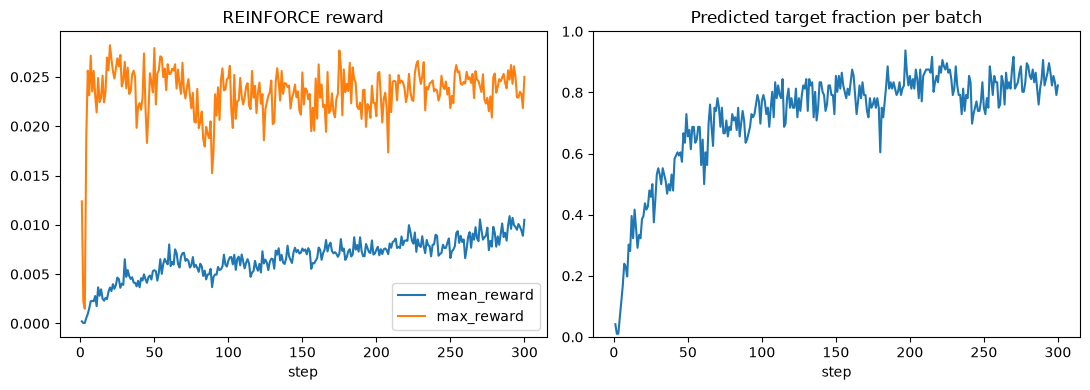

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rl_history_frame.plot(x="step", y=["mean_reward", "max_reward"], ax=axes[0])
rl_history_frame.plot(x="step", y="predicted_target_fraction", ax=axes[1], legend=False)
axes[0].set_title("REINFORCE reward")
axes[1].set_title("Predicted target fraction per batch")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 10. Generate, filter, deduplicate, and export

The final file contains every unique, UVVisML-novel molecule from this sampling run that passes
all hard filters **and** has its predicted mean lambda-max inside the configured UV interval.
The audit CSV retains every rejected or out-of-target proposal and its reason/properties.

In [14]:
seed_everything(SEED + 999)
proposal_smiles = []
while len(proposal_smiles) < FINAL_SAMPLES:
    batch_size = min(CFG.final_batch_size, FINAL_SAMPLES - len(proposal_smiles))
    batch_smiles, _ = sample_token_sequences(agent, batch_size, CFG.sampling_temperature)
    proposal_smiles.extend(batch_smiles)

proposal_audit = score_smiles_batch(proposal_smiles)
proposal_audit.to_csv(OUTPUT_DIR / "generated_proposals_audit.csv", index=False)

generated = proposal_audit[
    proposal_audit["passes_hard_filters"]
    & proposal_audit["novel_vs_uvvisml"]
    & proposal_audit["in_target_predicted"]
].copy()
generated = generated.drop_duplicates("canonical_smiles")
generated["target_low_nm"] = CFG.target_low_nm
generated["target_high_nm"] = CFG.target_high_nm
generated = generated.sort_values(
    ["in_target_predicted", "reward", "prediction_std_nm"],
    ascending=[False, False, True],
).reset_index(drop=True)

export_columns = [
    "canonical_smiles",
    "predicted_lambda_max_nm",
    "prediction_std_nm",
    "target_low_nm",
    "target_high_nm",
    "in_target_predicted",
    "uv_interval_score",
    "reward",
    "molecular_weight",
    "sa_score",
    "qed",
    "rotatable_bonds",
    "psoralen_similarity",
    "max_train_tanimoto",
    "novel_vs_uvvisml",
    "passes_hard_filters",
    "filter_reason",
]
GENERATED_DATASET_PATH = ROOT / "generated_uv_molecules.csv"
generated[export_columns].to_csv(GENERATED_DATASET_PATH, index=False)
if generated.empty:
    raise RuntimeError(
        "No molecule passed the filters. Increase final_samples or training steps; do not relax safety silently."
    )

print(f"Exported {len(generated):,} unique valid novel molecules to {GENERATED_DATASET_PATH}")
print(f"Predicted in target: {int(generated['in_target_predicted'].sum()):,}")
display(generated[export_columns].head(20))

Exported 2,155 unique valid novel molecules to /home/dokoo-lua/MolGeneration/generated_uv_molecules.csv
Predicted in target: 2,155


,canonical_smiles,predicted_lambda_max_nm,prediction_std_nm,target_low_nm,target_high_nm,in_target_predicted,uv_interval_score,reward,molecular_weight,sa_score,qed,rotatable_bonds,psoralen_similarity,max_train_tanimoto,novel_vs_uvvisml,passes_hard_filters,filter_reason
0,c1ccc(Nc2cncnc2Nc2ccccc2)cc1,349.222593,58.088587,300.0,400.0,True,0.113861,0.026236,262.316,1.898493,0.746761,4,0.085106,0.400000,True,True,ok
1,COc1ccccc1-c1ccccn1,351.427074,58.088587,300.0,400.0,True,0.113608,0.026128,185.226,1.480776,0.717291,2,0.142857,0.432432,True,True,ok
2,Oc1cccnc1Oc1cccnc1Oc1ccccc1,353.324341,58.088587,300.0,400.0,True,0.112033,0.026076,280.283,2.219244,0.787744,4,0.089286,0.380000,True,True,ok
3,COc1cccnc1Oc1cccnc1OC,351.533253,58.088587,300.0,400.0,True,0.113552,0.026062,232.239,2.158505,0.809019,4,0.145833,0.351351,True,True,ok
4,Oc1ccccc1OCc1ccccc1-c1ccccn1,349.965132,58.088587,300.0,400.0,True,0.113967,0.025887,277.323,1.835344,0.782436,4,0.072727,0.355556,True,True,ok
5,COc1ccccc1OCc1ccccc1Cl,350.643374,58.088587,300.0,400.0,True,0.113894,0.025684,248.709,1.409592,0.816352,4,0.137255,0.333333,True,True,ok
6,COc1ccccc1Oc1cccnc1C,351.429715,58.088587,300.0,400.0,True,0.113607,0.025517,215.252,1.699119,0.787482,3,0.140000,0.342857,True,True,ok
7,c1ccc(OCc2ncccc2-c2ccccn2)cc1,348.896094,58.088587,300.0,400.0,True,0.113752,0.025467,262.312,1.876395,0.718378,4,0.076923,0.380952,True,True,ok
8,COc1ccccc1OCc1ncccn1,346.735866,58.088587,300.0,400.0,True,0.112101,0.025420,216.240,1.782716,0.784299,4,0.142857,0.352941,True,True,ok
9,COc1ccccc1Oc1ccncc1,353.308590,58.088587,300.0,400.0,True,0.112051,0.025396,201.225,1.605471,0.764686,3,0.145833,0.363636,True,True,ok


## 11. Metrics and provenance manifest

The manifest records the code revision, source content hash, seeds, packages, configuration,
model paths, and outcome counts. Negative outcomes remain visible in the proposal audit.

In [15]:
def package_version(distribution: str) -> str:
    try:
        return importlib_metadata.version(distribution)
    except importlib_metadata.PackageNotFoundError:
        return "not-installed"


try:
    git_revision = subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
    ).stdout.strip()
except Exception:
    git_revision = "unavailable"

reason_counts = proposal_audit["filter_reason"].value_counts(dropna=False).to_dict()
generation_metrics = {
    "sampled_proposals": int(len(proposal_audit)),
    "unique_valid_novel_target": int(len(generated)),
    "predicted_in_target": int(generated["in_target_predicted"].sum()),
    "valid_novel_target_yield": float(len(generated) / max(len(proposal_audit), 1)),
    "target_yield": float(generated["in_target_predicted"].sum() / max(len(proposal_audit), 1)),
    "median_predicted_lambda_max_nm": float(generated["predicted_lambda_max_nm"].median()),
    "median_prediction_std_nm": float(generated["prediction_std_nm"].median()),
    "median_sa_score": float(generated["sa_score"].median()),
    "filter_reason_counts": {str(key): int(value) for key, value in reason_counts.items()},
}

manifest = {
    "purpose": "de novo SELFIES-GRU generation optimised by a UV lambda-max surrogate",
    "scientific_scope": (
        "Predicted lambda_max prioritisation only; not experimental absorption strength, "
        "non-toxicity, or confirmed synthesis."
    ),
    "git_revision": git_revision,
    "seed": SEED,
    "device": str(DEVICE),
    "platform": platform.platform(),
    "python": platform.python_version(),
    "packages": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "rdkit": rdBase.rdkitVersion,
        "torch": torch.__version__,
        "selfies": package_version("selfies"),
    },
    "source": {
        "urls": list(CFG.source_urls),
        "cached_paths": {name: str(path) for name, path in RAW_DATA_PATHS.items()},
        "sha256": SOURCE_SHA256,
        "raw_rows": int(len(raw)),
        "usable_measurements": int(len(clean)),
        "unique_molecules": int(len(uv_data)),
    },
    "split_counts": {
        name: int(value) for name, value in uv_data["split"].value_counts().to_dict().items()
    },
    "config": asdict(CFG),
    "effective_run": {
        "prior_epochs": PRIOR_EPOCHS,
        "rl_steps": RL_STEPS,
        "final_samples": FINAL_SAMPLES,
    },
    "artifacts": {
        "generated_dataset": str(GENERATED_DATASET_PATH),
        "proposal_audit": str(OUTPUT_DIR / "generated_proposals_audit.csv"),
        "reviewer": str(MODEL_DIR / "uv_rf_ensemble.joblib"),
        "prior": str(MODEL_DIR / "selfies_prior.pt"),
        "agent": str(MODEL_DIR / "selfies_uv_agent.pt"),
    },
    "reviewer_metrics": reviewer_metrics.to_dict(orient="records"),
    "generation_metrics": generation_metrics,
}

with (OUTPUT_DIR / "generation_metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(generation_metrics, handle, indent=2, ensure_ascii=False)
with (OUTPUT_DIR / "run_manifest.json").open("w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2, ensure_ascii=False)

display(pd.Series(generation_metrics).drop("filter_reason_counts"))
print(f"Manifest: {OUTPUT_DIR / 'run_manifest.json'}")

sampled_proposals                      3000
unique_valid_novel_target              2155
predicted_in_target                    2155
valid_novel_target_yield           0.718333
target_yield                       0.718333
median_predicted_lambda_max_nm     362.0612
median_prediction_std_nm          58.088587
median_sa_score                    2.131801
dtype: object

Manifest: /home/dokoo-lua/MolGeneration/outputs/uv_denovo/run_manifest.json


## Reading the output

- `generated_uv_molecules.csv` — the requested final dataset of unique, valid, novel candidates.
- `outputs/uv_denovo/generated_proposals_audit.csv` — all final proposals, including failures.
- `outputs/uv_denovo/reviewer_metrics.csv` — held-out scaffold metrics; inspect these before trusting
  the ranking.
- `outputs/uv_denovo/run_manifest.json` — source hash, versions, seeds, configuration, and paths.
- `outputs/uv_denovo/models/` — RF reviewer, frozen prior, and RL agent checkpoints.

The next scientifically meaningful step is to take a diverse top subset and recompute spectra with
an independent method (for example sTDA/TD-DFT), followed by experimental review. Do not label the
CSV molecules “safe” or “UV absorbers” solely from this notebook.